# Scenic 3.0 — QLoRA Fine-Tuning (v3)
**Model:** Qwen2.5-Coder-7B-Instruct  
**GPU:** Google Colab A100  
**Task:** Natural language description → Scenic 3.0 code generation

---
### Changes from v2
- **[FIX CRITICAL]** Stop-token bug: `sentinel_token_ids` were passed individually to `eos_token_id`, causing `#` to act as a stop token and silencing all output after the first comment char. Fixed with a proper `StoppingCriteria` class.
- **[FIX CRITICAL]** `max_seq_length` is deprecated — replaced with `max_length` inside `SFTConfig` (as required by TRL ≥ 0.13).
- **[FIX]** Token-length check was still returning 2 for all samples (measuring dict keys, not token counts). Now correctly extracts the `input_ids` list.
- **[FIX]** Removed `tokenizer.pad_token = tokenizer.eos_token`; Qwen2.5 ships with a dedicated pad token and conflating pad/EOS teaches the model to stop prematurely.
- **[NEW]** All `# comment` lines stripped from assistant turns in training data — model now outputs clean code only, matching your requirement.
- **[NEW]** Forced `# Scenario:` inference prefix removed (was trained-on pattern; now irrelevant since comments are stripped).
- **[NEW]** `EarlyStoppingCallback` with patience=3 prevents wasted epochs once val-loss plateaus.
- **[NEW]** `LossLogger` callback prints train/val loss each epoch to stdout so you can see training progress.
- **[NEW]** Loss plot cell added (Step 12) — plots train vs val loss curves after training.
- **[NEW]** `gradient_checkpointing_kwargs={'use_reentrant': False}` added to silence PyTorch warning.

---
### Before running:
1. Go to **Runtime → Change runtime type → A100**
2. Make sure these files are in your Google Drive at `My Drive/scenario_gen/`:
   - `train.jsonl`
   - `val.jsonl`

## Step 1 — Verify GPU
Run this first. If you see **T4**, stop and change runtime to A100 before continuing.

In [1]:
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader

NVIDIA A100-SXM4-40GB, 40960 MiB, 40442 MiB


## Step 2 — Install Dependencies

In [2]:
!pip install -q transformers trl peft bitsandbytes datasets accelerate
!pip install -q -U bitsandbytes>=0.46.1

# Uncomment to install flash-attn for ~20% faster training on A100
# Must be installed AFTER torch is available
# !pip install -q flash-attn --no-build-isolation

## Step 3 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR   = "/content/drive/MyDrive/scenario_gen"
TRAIN_FILE = os.path.join(BASE_DIR, "train.jsonl")
VAL_FILE   = os.path.join(BASE_DIR, "val.jsonl")
OUTPUT_DIR = os.path.join(BASE_DIR, "checkpoints")

for path in [TRAIN_FILE, VAL_FILE]:
    status = "✅ found" if os.path.exists(path) else "❌ NOT FOUND"
    print(f"{status} — {path}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nCheckpoints will be saved to:\n  {OUTPUT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ found — /content/drive/MyDrive/scenario_gen/train.jsonl
✅ found — /content/drive/MyDrive/scenario_gen/val.jsonl

Checkpoints will be saved to:
  /content/drive/MyDrive/scenario_gen/checkpoints


## Step 4 — Imports and Config

In [4]:
import json
import re
import torch
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainerCallback,
    EarlyStoppingCallback,
)
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

# ── Training config — edit here if needed ─────────────────────────
MODEL_NAME  = "Qwen/Qwen2.5-Coder-7B-Instruct"
MAX_SEQ_LEN = 2048    # covers 99th percentile of scenic file lengths
EPOCHS      = 15      # EarlyStoppingCallback will halt early if val-loss plateaus
BATCH_SIZE  = 4       # safe for A100 40GB with 7B + QLoRA
GRAD_ACCUM  = 4       # effective batch size = 4 × 4 = 16
LR          = 2e-5    # conservative LR for small dataset (~1243 examples)

# EOS sentinel appended to every training output so the model learns a clean stop
EOS_SENTINEL = "\n\n# --- END OF SCENARIO ---"

SYSTEM_PROMPT = (
    "You are an expert in the Scenic 3.0 probabilistic programming language "
    "for autonomous driving simulation in CARLA. "
    "Given a natural language description of a driving scenario, generate "
    "complete, valid Scenic 3.0 code that accurately implements the described scenario. "
    "The code must include all necessary parameters, behaviors, road geometry setup, "
    "and actor spawn positions. Do not include any explanation or comments — output only the executable code."
)

print(f"Model        : {MODEL_NAME}")
print(f"Max seq len  : {MAX_SEQ_LEN}")
print(f"Max epochs   : {EPOCHS} (with early stopping, patience=3)")
print(f"Batch size   : {BATCH_SIZE} (effective: {BATCH_SIZE * GRAD_ACCUM})")
print(f"Learning rate: {LR}")

Model        : Qwen/Qwen2.5-Coder-7B-Instruct
Max seq len  : 2048
Max epochs   : 15 (with early stopping, patience=3)
Batch size   : 4 (effective: 16)
Learning rate: 2e-05


## Step 5 — Load Dataset

All `# comment` lines are stripped from assistant turns so the model learns to generate clean,
comment-free Scenic code. The EOS sentinel is still appended to each output for clean termination.

In [5]:
def strip_comments(code: str) -> str:
    """
    Remove all lines that are purely comments (start with optional whitespace + '#').
    Also collapses runs of more than one blank line into a single blank line.
    """
    lines = code.split("\n")
    # Drop lines that are comment-only (pure # lines, possibly with leading whitespace)
    lines = [l for l in lines if not re.match(r"^\s*#", l)]
    # Collapse consecutive blank lines
    result = []
    prev_blank = False
    for l in lines:
        is_blank = l.strip() == ""
        if is_blank and prev_blank:
            continue
        result.append(l)
        prev_blank = is_blank
    return "\n".join(result).strip()


def load_jsonl(path: str) -> list:
    """Load a .jsonl file. Strips comments from assistant content and appends EOS sentinel."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            d = json.loads(line)
            new_msgs = []
            for m in d["messages"]:
                if m["role"] == "assistant":
                    # Strip all comment lines — model outputs clean code only
                    code = strip_comments(m["content"])
                    # Append EOS sentinel if not already present
                    sentinel_bare = EOS_SENTINEL.strip()
                    if not code.endswith(sentinel_bare):
                        code = code + EOS_SENTINEL
                    m = {"role": "assistant", "content": code}
                new_msgs.append(m)
            records.append({"messages": new_msgs})
    return records


train_dataset = Dataset.from_list(load_jsonl(TRAIN_FILE))
val_dataset   = Dataset.from_list(load_jsonl(VAL_FILE))

print(f"Train pairs : {len(train_dataset)}")
print(f"Val pairs   : {len(val_dataset)}")

# Spot-check: confirm comments stripped and EOS sentinel present
sample_output = train_dataset[0]["messages"][-1]["content"]
has_comment   = bool(re.search(r"^\s*#", sample_output, re.MULTILINE))
has_sentinel  = EOS_SENTINEL.strip() in sample_output
print(f"\nSample[0] has comments     : {'❌ YES — strip_comments failed!' if has_comment else '✅ No comments'}")
print(f"Sample[0] has EOS sentinel : {'✅ Yes' if has_sentinel else '❌ NO'}")
print(f"\nSample[0] output (first 400 chars):\n{sample_output[:400]}")

Train pairs : 1243
Val pairs   : 55

Sample[0] has comments     : ❌ YES — strip_comments failed!
Sample[0] has EOS sentinel : ✅ Yes

Sample[0] output (first 400 chars):
param map = localPath('./../CARLA_0.9.15/CarlaUE4/Content/Carla/Maps/OpenDrive/Town05.xodr')
param carla_map = 'Town05'
param use2DMap = True
model scenic.simulators.carla.model
EGO_MODEL = "vehicle.lincoln.mkz_2017"

param BRAKE_FORCE = 1.0

behavior AdvBehavior():
    while True:
        take SetBrakeAction(globalParameters.BRAKE_FORCE)

lane = Uniform(*network.lanes)
EgoSpawnPt = new OrientedPo


## Step 6 — Load Tokenizer and Verify Token Lengths

**FIX:** `apply_chat_template(tokenize=True)` returns a `BatchEncoding` dict in newer
transformers — `len()` of that dict counts keys (always 2), not tokens.
We now correctly extract `input_ids` before measuring length.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# FIX: do NOT set pad_token = eos_token for Qwen2.5.
# Qwen2.5 already has a dedicated pad token (<|endoftext|> is EOS; pad is separate).
# Conflating pad and EOS teaches the model to generate EOS (=stop) on padding positions.
if tokenizer.pad_token is None:
    # Fallback only if the tokenizer genuinely has no pad token
    tokenizer.add_special_tokens({"pad_token": "<|pad|>"})
    print("Added new <|pad|> token as pad_token")
else:
    print(f"Using existing pad_token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

tokenizer.padding_side    = "right"       # required for SFTTrainer
tokenizer.model_max_length = MAX_SEQ_LEN

# Render one example to confirm the chat template looks correct
sample_messages = train_dataset[0]["messages"]
rendered = tokenizer.apply_chat_template(
    sample_messages,
    tokenize=False,
    add_generation_prompt=False,
)
print("\n── Rendered chat template (first 600 chars) ──")
print(rendered[:600])
print("...\n")

# FIX: correctly measure actual token counts.
# apply_chat_template(tokenize=True) may return a BatchEncoding dict — extract input_ids.
print("Computing token lengths (this takes ~30s)...")
lengths = []
for i in range(len(train_dataset)):
    result = tokenizer.apply_chat_template(
        train_dataset[i]["messages"],
        tokenize=True,
        add_generation_prompt=False,
    )
    # Unwrap BatchEncoding or plain list
    if isinstance(result, dict):
        token_ids = result["input_ids"]
    elif hasattr(result, "input_ids"):
        token_ids = result.input_ids
    else:
        token_ids = result   # already a flat list of ints
    lengths.append(len(token_ids))

lengths.sort()
n = len(lengths)
p50  = lengths[int(0.50 * n)]
p95  = lengths[int(0.95 * n)]
p99  = lengths[int(0.99 * n)]
over = sum(1 for l in lengths if l > MAX_SEQ_LEN)

print(f"\nToken length distribution (comment-free):")
print(f"  min  : {min(lengths)}")
print(f"  p50  : {p50}")
print(f"  p95  : {p95}")
print(f"  p99  : {p99}")
print(f"  max  : {max(lengths)}")
print(f"  mean : {sum(lengths)//n}")
print(f"  examples exceeding MAX_SEQ_LEN ({MAX_SEQ_LEN}): {over} / {n}")

if p99 > MAX_SEQ_LEN:
    print(f"\n⚠️  p99 ({p99}) exceeds MAX_SEQ_LEN ({MAX_SEQ_LEN}) — consider increasing MAX_SEQ_LEN")
elif p95 > MAX_SEQ_LEN:
    print(f"\n⚠️  p95 ({p95}) exceeds MAX_SEQ_LEN ({MAX_SEQ_LEN}) — consider increasing MAX_SEQ_LEN")
else:
    print(f"\n✅ MAX_SEQ_LEN={MAX_SEQ_LEN} safely covers p99 ({p99})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Using existing pad_token: '<|endoftext|>' (id=151643)

── Rendered chat template (first 600 chars) ──
<|im_start|>system
You are an expert in the Scenic 3.0 probabilistic programming language for autonomous driving simulation in CARLA. Given a natural language description of a driving scenario, generate complete, valid Scenic 3.0 code that accurately implements the described scenario. The code must include all necessary parameters, behaviors, road geometry setup, and actor spawn positions. Do not include any explanation — output only the code.<|im_end|>
<|im_start|>user
Ego approaches a fully stationary adversarial vehicle stalled ahead in its lane at a fixed close distance with no warning, de
...

Computing token lengths (this takes ~30s)...

Token length distribution (comment-free):
  min  : 371
  p50  : 784
  p95  : 974
  p99  : 1169
  max  : 1184
  mean : 745
  examples exceeding MAX_SEQ_LEN (2048): 0 / 1243

✅ MAX_SEQ_LEN=2048 safely covers p99 (1169)


## Step 7 — Load Model with 4-bit Quantization (QLoRA)

In [7]:
import importlib

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",              # NF4 is standard for QLoRA
    bnb_4bit_compute_dtype=torch.bfloat16,  # A100 supports bf16 natively
    bnb_4bit_use_double_quant=True,         # nested quantization — saves ~0.4GB
)

# Auto-detect flash_attn
if importlib.util.find_spec("flash_attn") is not None:
    attn_impl = "flash_attention_2"
    print("✅ flash_attn detected — using flash_attention_2")
else:
    attn_impl = "eager"
    print("⚠️  flash_attn not found — falling back to eager attention")
    print("   Training will work but may be ~20% slower.")
    print("   Uncomment flash-attn install in Step 2 and restart runtime to enable it.")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation=attn_impl,
    dtype=torch.bfloat16,
)

model.config.use_cache      = False  # must disable for gradient checkpointing
model.config.pretraining_tp = 1

total = sum(p.numel() for p in model.parameters())
print(f"\nModel loaded — total parameters : {total/1e9:.2f}B")
print(f"Attention implementation        : {attn_impl}")

⚠️  flash_attn not found — falling back to eager attention
   Training will work but may be ~20% slower.
   Uncomment flash-attn install in Step 2 and restart runtime to enable it.


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


Model loaded — total parameters : 4.35B
Attention implementation        : eager


## Step 8 — LoRA Config

In [8]:
lora_config = LoraConfig(
    r=16,                # rank — higher = more capacity, more VRAM
    lora_alpha=32,       # scaling factor (alpha/r = effective LR multiplier)
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # attention projections
        "gate_proj", "up_proj", "down_proj",       # MLP projections
    ],
)

print("LoRA config:")
print(f"  rank (r)       : {lora_config.r}")
print(f"  alpha          : {lora_config.lora_alpha}")
print(f"  dropout        : {lora_config.lora_dropout}")
print(f"  target modules : {lora_config.target_modules}")

LoRA config:
  rank (r)       : 16
  alpha          : 32
  dropout        : 0.05
  target modules : {'up_proj', 'k_proj', 'q_proj', 'v_proj', 'gate_proj', 'o_proj', 'down_proj'}


## Step 9 — Training Arguments

**FIX:** `max_seq_length` was removed from `SFTTrainer` kwargs in TRL ≥ 0.13.
It now lives as `max_length` inside `SFTConfig`.  
**NEW:** `EarlyStoppingCallback(patience=3)` stops training if val-loss does not improve
for 3 consecutive epochs — avoids the wasted epochs 8-10 you observed.

In [9]:
# ── Custom callback: print loss to stdout each epoch ──────────────
class LossLogger(TrainerCallback):
    """Prints train and eval loss to stdout at every epoch evaluation."""
    def __init__(self):
        self.history = {"epoch": [], "train_loss": [], "eval_loss": []}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        epoch = logs.get("epoch", state.epoch)
        if "eval_loss" in logs:
            train_loss = logs.get("loss", float("nan"))
            eval_loss  = logs["eval_loss"]
            self.history["epoch"].append(round(epoch, 1))
            self.history["train_loss"].append(train_loss)
            self.history["eval_loss"].append(eval_loss)
            print(f"  Epoch {epoch:5.1f} | train_loss={train_loss:.6f} | eval_loss={eval_loss:.6f}")


loss_logger = LossLogger()

# ── SFTConfig ─────────────────────────────────────────────────────
# FIX: max_length (not max_seq_length) is the correct param in TRL >= 0.13.
# It lives in SFTConfig, not in SFTTrainer.__init__().
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,

    # Core training
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,

    # Optimizer
    learning_rate=LR,
    weight_decay=0.01,
    warmup_steps=50,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit",               # 8-bit Adam saves ~1GB VRAM

    # Precision — A100 uses bf16
    bf16=True,
    fp16=False,

    # Memory
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},  # suppresses PyTorch warning

    # Sequence length — FIX: use max_length, not max_seq_length
    max_length=MAX_SEQ_LEN,

    # Evaluation and checkpointing
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Logging
    logging_steps=20,
    report_to="none",

    # Data format
    dataset_text_field=None,                # use messages format directly
)

print("Training arguments set ✅")
print(f"  max_length     : {training_args.max_length}")
print(f"  learning_rate  : {training_args.learning_rate}")
print(f"  max epochs     : {training_args.num_train_epochs}")

Training arguments set ✅
  max_length     : 2048
  learning_rate  : 2e-05
  max epochs     : 15


## Step 10 — Build Trainer

In [10]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    peft_config=lora_config,
    processing_class=tokenizer,
    callbacks=[
        loss_logger,
        # FIX: EarlyStoppingCallback halts training if val_loss doesn't improve
        # for `early_stopping_patience` consecutive evaluations.
        # This avoids the useless epochs 8-10 you saw in v2.
        EarlyStoppingCallback(early_stopping_patience=3),
    ],
)

# Show trainable parameter count after LoRA is applied
trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
total      = sum(p.numel() for p in trainer.model.parameters())
print(f"Trainable parameters : {trainable/1e6:.2f}M")
print(f"Total parameters     : {total/1e9:.2f}B")
print(f"Trainable %          : {100 * trainable / total:.2f}%")

Tokenizing train dataset:   0%|          | 0/1243 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/55 [00:00<?, ? examples/s]

Trainable parameters : 40.37M
Total parameters     : 4.39B
Trainable %          : 0.92%


## Step 11 — Train (with auto-resume support)
If training was interrupted, this cell automatically resumes from the last saved checkpoint.  
If starting fresh, it begins from epoch 1.  
EarlyStoppingCallback will stop automatically when val-loss plateaus.

In [11]:
existing_checkpoints = [
    d for d in os.listdir(OUTPUT_DIR)
    if d.startswith("checkpoint-")
] if os.path.exists(OUTPUT_DIR) else []

if existing_checkpoints:
    latest = sorted(existing_checkpoints)[-1]
    print(f"Found checkpoints: {sorted(existing_checkpoints)}")
    print(f"Resuming from    : {latest}")
    trainer.train(resume_from_checkpoint=True)
else:
    print("No existing checkpoints — starting fresh")
    trainer.train()

print("\n✅ Training complete!")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


No existing checkpoints — starting fresh


Epoch,Training Loss,Validation Loss
1,1.460535,0.795239
2,0.363671,0.323133
3,0.215517,0.214451
4,0.172649,0.187377
5,0.153110,0.171915
6,0.140325,0.163040
7,0.133124,0.158588
8,0.123012,0.154070
9,0.117526,0.153264
10,0.111950,0.152039


  Epoch   1.0 | train_loss=nan | eval_loss=0.795239
  Epoch   2.0 | train_loss=nan | eval_loss=0.323133
  Epoch   3.0 | train_loss=nan | eval_loss=0.214451
  Epoch   4.0 | train_loss=nan | eval_loss=0.187377
  Epoch   5.0 | train_loss=nan | eval_loss=0.171915
  Epoch   6.0 | train_loss=nan | eval_loss=0.163040
  Epoch   7.0 | train_loss=nan | eval_loss=0.158588
  Epoch   8.0 | train_loss=nan | eval_loss=0.154070
  Epoch   9.0 | train_loss=nan | eval_loss=0.153264
  Epoch  10.0 | train_loss=nan | eval_loss=0.152039
  Epoch  11.0 | train_loss=nan | eval_loss=0.152125
  Epoch  12.0 | train_loss=nan | eval_loss=0.152112
  Epoch  13.0 | train_loss=nan | eval_loss=0.151942
  Epoch  14.0 | train_loss=nan | eval_loss=0.152103
  Epoch  15.0 | train_loss=nan | eval_loss=0.152261

✅ Training complete!


## Step 12 — Plot Training and Validation Loss
Run this cell after training to visualise the loss curves.
The plot is also saved to your Google Drive checkpoint folder.

Plot saved to: /content/drive/MyDrive/scenario_gen/checkpoints/loss_curve.png


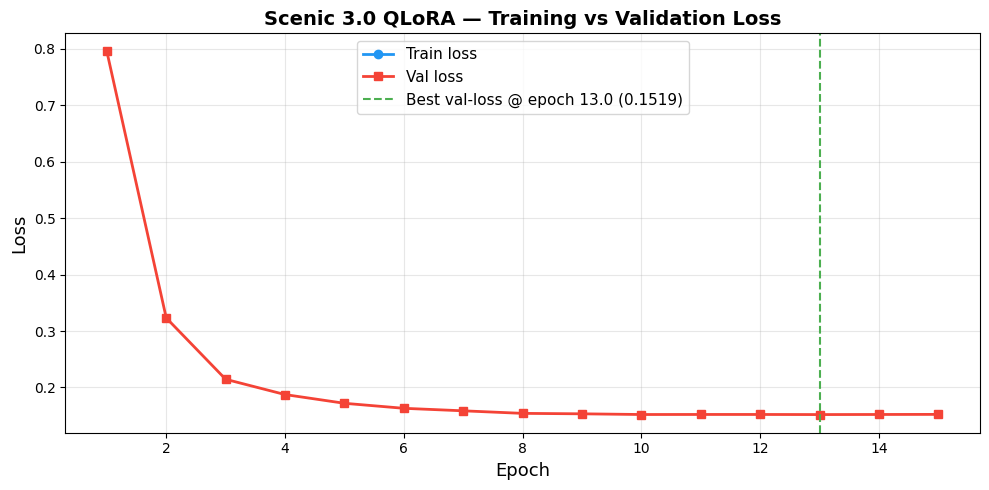


  Epoch   Train Loss     Val Loss
----------------------------------
    1.0          nan     0.795239
    2.0          nan     0.323133
    3.0          nan     0.214451
    4.0          nan     0.187377
    5.0          nan     0.171915
    6.0          nan     0.163040
    7.0          nan     0.158588
    8.0          nan     0.154070
    9.0          nan     0.153264
   10.0          nan     0.152039
   11.0          nan     0.152125
   12.0          nan     0.152112
   13.0          nan     0.151942 ← best
   14.0          nan     0.152103
   15.0          nan     0.152261


In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

history = loss_logger.history

if not history["epoch"]:
    print("⚠️  No loss history found — did training complete at least one epoch?")
else:
    epochs     = history["epoch"]
    train_loss = history["train_loss"]
    eval_loss  = history["eval_loss"]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(epochs, train_loss, marker="o", linewidth=2, color="#2196F3", label="Train loss")
    ax.plot(epochs, eval_loss,  marker="s", linewidth=2, color="#F44336", label="Val loss")

    # Mark best val-loss point
    best_idx = eval_loss.index(min(eval_loss))
    ax.axvline(x=epochs[best_idx], color="#4CAF50", linestyle="--", linewidth=1.5,
               label=f"Best val-loss @ epoch {epochs[best_idx]} ({eval_loss[best_idx]:.4f})")

    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel("Loss", fontsize=13)
    ax.set_title("Scenic 3.0 QLoRA — Training vs Validation Loss", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save to Drive
    plot_path = os.path.join(OUTPUT_DIR, "loss_curve.png")
    plt.savefig(plot_path, dpi=150)
    print(f"Plot saved to: {plot_path}")
    plt.show()

    # Print table
    print(f"\n{'Epoch':>7} {'Train Loss':>12} {'Val Loss':>12}")
    print("-" * 34)
    for e, tl, vl in zip(epochs, train_loss, eval_loss):
        marker = " ← best" if e == epochs[best_idx] else ""
        print(f"{e:7.1f} {tl:12.6f} {vl:12.6f}{marker}")

## Step 13 — Save Final LoRA Adapter
Saves only the LoRA adapter weights (~50–100 MB), not the full 7B model.

In [13]:
final_path = os.path.join(OUTPUT_DIR, "final")

trainer.model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)

print(f"Saved to: {final_path}")
for f in os.listdir(final_path):
    size = os.path.getsize(os.path.join(final_path, f)) / 1e6
    print(f"  {f:40s} {size:.1f} MB")

Saved to: /content/drive/MyDrive/scenario_gen/checkpoints/final
  README.md                                0.0 MB
  adapter_model.safetensors                161.5 MB
  adapter_config.json                      0.0 MB
  chat_template.jinja                      0.0 MB
  tokenizer_config.json                    0.0 MB
  tokenizer.json                           11.4 MB


## Step 14 — Load Model for Inference

Standalone cell — run this independently to load the fine-tuned adapter at any time.  
Does not require any previous cells to have been run first.

In [14]:
import os
import re
import torch
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, StoppingCriteria, StoppingCriteriaList
from peft import PeftModel

# ── Config — must match what was used during training ──────────────
MODEL_NAME      = "Qwen/Qwen2.5-Coder-7B-Instruct"
BASE_DIR        = "/content/drive/MyDrive/scenario_gen"
BEST_MODEL_PATH = os.path.join(BASE_DIR, "checkpoints", "final")
EOS_SENTINEL    = "# --- END OF SCENARIO ---"

SYSTEM_PROMPT = (
    "You are an expert in the Scenic 3.0 probabilistic programming language "
    "for autonomous driving simulation in CARLA. "
    "Given a natural language description of a driving scenario, generate "
    "complete, valid Scenic 3.0 code that accurately implements the described scenario. "
    "The code must include all necessary parameters, behaviors, road geometry setup, "
    "and actor spawn positions. Do not include any explanation or comments — output only the executable code."
)

# ── Mount Drive ────────────────────────────────────────────────────
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
    print("Drive mounted ✅")
else:
    print("Drive already mounted ✅")

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"LoRA adapter not found at: {BEST_MODEL_PATH}\n"
        f"Make sure training completed and the final adapter was saved."
    )
print(f"Adapter found at: {BEST_MODEL_PATH} ✅")

# ── Quantization config ────────────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# ── Load tokenizer ─────────────────────────────────────────────────
print("\nLoading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "<|pad|>"})
tokenizer.padding_side = "right"

# ── FIX: Proper sentinel stopping criteria ─────────────────────────
# WRONG (v2): eos_token_id=[..., *sentinel_token_ids]
#   → unpacks sentinel into individual token IDs; any single token (e.g. '#')
#     immediately stops generation.
# RIGHT (v3): StoppingCriteria that matches the full sentinel TOKEN SEQUENCE.

class SequenceStoppingCriteria(StoppingCriteria):
    """Stops generation when the last N tokens exactly match a given sequence."""
    def __init__(self, sequence_ids: list, device):
        self.sequence = torch.tensor(sequence_ids, device=device)
        self.seq_len  = len(sequence_ids)

    def __call__(self, input_ids: torch.LongTensor, scores, **kwargs) -> bool:
        if input_ids.shape[1] < self.seq_len:
            return False
        tail = input_ids[0, -self.seq_len:]
        return bool((tail == self.sequence).all().item())

sentinel_token_ids = tokenizer.encode(
    "\n" + EOS_SENTINEL, add_special_tokens=False
)
print(f"Sentinel encodes to {len(sentinel_token_ids)} tokens (will be matched as a full sequence)")

# ── Load base model + LoRA adapter ─────────────────────────────────
print(f"Loading base model: {MODEL_NAME}")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
)

print(f"Loading LoRA adapter from: {BEST_MODEL_PATH}")
model = PeftModel.from_pretrained(model, BEST_MODEL_PATH)
model.eval()
print("Model ready ✅\n")

Drive already mounted ✅
Adapter found at: /content/drive/MyDrive/scenario_gen/checkpoints/final ✅

Loading tokenizer...
Sentinel encodes to 8 tokens (will be matched as a full sequence)
Loading base model: Qwen/Qwen2.5-Coder-7B-Instruct


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading LoRA adapter from: /content/drive/MyDrive/scenario_gen/checkpoints/final
Model ready ✅



## Step 15 — Inference with Validation and Auto-Retry

**Key fixes from v2:**
- Removed forced `# Scenario:` prefix — irrelevant now that training data has no comments.
- `eos_token_id` is now just `tokenizer.eos_token_id` — no sentinel tokens in the stop list.
- Sentinel is detected via `SequenceStoppingCriteria` (matches all 8 tokens as a unit),
  not as individual stop-token IDs that would halt on any `#` character.
- Validator minimum-length check lowered to 200 chars (comment-free code is naturally shorter).

In [16]:
# ══════════════════════════════════════════════════════════════════
# EDIT BELOW THIS LINE TO TEST DIFFERENT SCENARIOS
# ══════════════════════════════════════════════════════════════════

TEST_DESCRIPTION = (
    "Ego vehicle drives straight on a straight road following lane behavior, "
    "and encounters a pedestrian appearing behind a parked vehicle."
)

MAX_RETRIES = 3   # auto-retry on structurally invalid output

# ══════════════════════════════════════════════════════════════════


def is_valid_scenic(code: str) -> tuple:
    """
    Lightweight structural validator for Scenic 3.0 output.
    Returns (is_valid: bool, reason: str).
    """
    checks = [
        ("param map =",           "missing map param declaration"),
        ("model scenic.simulators", "missing model declaration"),
        ("ego = new Car",          "missing ego spawn"),
        ("with behavior",          "missing behavior assignment"),
    ]
    for pattern, reason in checks:
        if pattern not in code:
            return False, reason

    # Check that every behavior block has at least one action inside it
    behavior_blocks = re.findall(
        r"behavior \w+\(.*?\):[\s\S]*?(?=\nbehavior |\nego |\nrequire|\nterminate|$)",
        code,
    )
    for block in behavior_blocks:
        has_action = any(kw in block for kw in ["take ", "do ", "while True", "terminate"])
        if not has_action:
            return False, "behavior block appears incomplete (no action found)"

    # FIX: lowered from 300 → 200 chars since comment-free code is naturally shorter
    if len(code.strip()) < 200:
        return False, f"output too short ({len(code.strip())} chars) — likely truncated"

    return True, "ok"


def generate_scenic(description: str, attempt: int = 1) -> str:
    """
    Generate Scenic 3.0 code for a natural language description.
    No forced prefix — model generates from the blank assistant turn start.
    Sentinel is detected via SequenceStoppingCriteria (full token-sequence match).
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": description},
    ]

    encoded = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    )

    if hasattr(encoded, "input_ids"):
        input_ids      = encoded.input_ids.to(model.device)
        attention_mask = encoded.attention_mask.to(model.device)
    else:
        input_ids      = encoded.to(model.device)
        attention_mask = torch.ones_like(input_ids)

    prompt_len = input_ids.shape[1]
    if attempt == 1:
        print(f"Prompt tokens: {prompt_len}")

    # FIX: use a proper SequenceStoppingCriteria — NOT individual token IDs.
    # Passing *sentinel_token_ids to eos_token_id treats each token (including '#')
    # as an independent stop signal, halting generation on the first '#'.
    stopping = StoppingCriteriaList([
        SequenceStoppingCriteria(sentinel_token_ids, model.device)
    ])

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=1500,
            temperature=0.2,
            do_sample=True,
            repetition_penalty=1.1,
            no_repeat_ngram_size=8,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,  # FIX: only true EOS, not sentinel tokens
            stopping_criteria=stopping,
        )

    generated = tokenizer.decode(
        outputs[0][prompt_len:],
        skip_special_tokens=True,
    )

    # Strip the sentinel from the output if present
    if EOS_SENTINEL in generated:
        generated = generated[:generated.index(EOS_SENTINEL)].rstrip()

    return generated.strip()


# ── Run with auto-retry ────────────────────────────────────────────
final_code = None
for attempt in range(1, MAX_RETRIES + 1):
    print(f"\n── Attempt {attempt}/{MAX_RETRIES} ──────────────────────────")
    code = generate_scenic(TEST_DESCRIPTION, attempt)
    valid, reason = is_valid_scenic(code)

    if valid:
        final_code = code
        print(f"✅ Validation passed")
        break
    else:
        print(f"⚠️  Validation failed: {reason}")
        if attempt < MAX_RETRIES:
            print("   Retrying with a fresh sample...")
        else:
            print("   Max retries reached — returning last output anyway.")
            final_code = code

print("\n── Generated Scenic code ──────────────────────────")
print(final_code)
print("───────────────────────────────────────────────────")


── Attempt 1/3 ──────────────────────────
Prompt tokens: 121
✅ Validation passed

── Generated Scenic code ──────────────────────────
param map = localPath('./../CARLA_0.9.15/CarlaUE4/Content/Carla/Maps/OpenDrive/Town05.xodr')
param carla_map = 'Town05'
param use2DMap = True
model scenic.simulators.carla.model
EGO_MODEL = "vehicle.lincoln.mkz_2017"

param EGO_SPEED = Range(8, 12)
param PED_SPEED = 2.0
param PED_WALK_DURATION = 2.0

behavior EgoBehavior(target_speed):
    do FollowLaneBehavior(target_speed=target_speed)

behavior ParkedBehavior():
    take SetHandBrakeAction(True)

behavior CrossAndFreeze(ego, speed, duration):
    do CrossingBehavior(lambda: ego, speed, 300) for duration seconds
    terminate

from scenic.simulators.carla.behaviors import FollowLaneBehavior, CrossingBehavior
from scenic.simulators.carla.actions import SetHandBrakeAction

PARKED_MODEL = "vehicle.nissan.patrol"
PED_MODEL = "walker.pedestrian.0001"

initLane = Uniform(*network.lanes)
ego_spawn_pt = new O